# <img src="https://img.icons8.com/bubbles/100/000000/3d-glasses.png" style="height:50px;display:inline"> CS 236873 - Technion - Computer Vision


## Assignment 3
---

### <a style='color:red'> Due Date: 24/06/2025  </a>

### <img src="https://img.icons8.com/bubbles/50/000000/upload-to-cloud.png" style="height:50px;display:inline"> Submission Guidelines
---
#### READ THIS CAREFULLY
* Submission only in **pairs**.
* **No handwritten submissions**.
* You can choose your working environment:
    * You can work in a `Jupyter Notebook`, locally with <a href="https://www.anaconda.com/distribution/">Anaconda</a> or online on <a href="https://colab.research.google.com/">Google Colab</a>
  * **Important**: Colab also supports running code on GPU, so if you don't have one, Colab is the way to go. To enable GPU on Colab, in the menu: `Runtime` $\rightarrow$  `Change Runtime Type` $\rightarrow$`GPU`.
    * You can work in a Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>.
        * Both also allow opening/editing Jupyter Notebooks.

* Make sure you submit your exercise according to the requirements in the "Homework submission guidelines" file that appears in the course website (Moodle). 
* **The code should run both on CPU and GPU without manual modifications**, require no special preparation and run on every computer.
* Be precise, we expect on point answers.
* Submission on the course website (Moodle).

### <img src="https://img.icons8.com/dusk/64/000000/python.png" style="height:50px;display:inline"> Python Libraries
---

* `numpy`
* `matplotlib`
* `pytorch` (and `torchvision`)
* `opencv` (or `scikit-image`)
* `scikit-learn`
* Anything else you need (`PIL`, `os`, `pandas`, `csv`, `json`,...)

For an easy initial installation you might use the following commands in your environment:
```


```

#### For colab run:

In [1]:
!pip install -q matplotlib numpy scipy opencv-python

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\dev\\Technion\\CV\\.venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



### Import

Include all your import in the following cell

In [2]:
import random

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
import scipy.optimize


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything()


%matplotlib inline

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Tasks
---
* In all tasks, you should document your process and results in a report file (which will be saved as `.pdf`). 
* You can reference your code in the report file, but no need for actual code in this file, the code is submitted in a seprate folder as explained above.

### <img src="https://img.icons8.com/external-itim2101-lineal-color-itim2101/64/000000/external-robot-engineering-itim2101-lineal-color-itim2101.png" style="height:50px;display:inline"> Introduction 
---
One of the major areas of computer vision is 3D reconstruction. Given several 2D images of an environment, can we recover the 3D structure of the environment, as well as the position of the camera/robot? This has many uses in robotics and autonomous systems, as understanding the 3D structure of the environment is crucial to navigation. You don't want your robot constantly bumping into walls, or running over human beings!

<center> <img src="https://research.qut.edu.au/qcr/wp-content/uploads/sites/305/2021/02/Challenge_summary_pic-768x513.jpg" style="height:300px">
<center> Image Source - <a href="https://research.qut.edu.au/qcr/2021/02/17/2nd-robotic-vision-scene-understanding-challenge-launched-cvpr2021-embodied-ai-workshop/"> CVPR 21 Embodied AI Workshop </a>

In Part 1, you will be writing a set of functions to generate a sparse point cloud for some test images we have provided to you. The test images are 2 renderings of a temple from two different angles. We have also provided you with a `npz` file containing good point correspondences between the two images. You will first write a function that computes the fundamental matrix between the two images. Then write a function that uses the epipolar constraint to find more point matches between the two images. Finally, you will write a function that will triangulate the 3D points for each pair of 2D point correspondences.



### <img src="https://img.icons8.com/pastel-glyph/64/000000/pain-points.png" style="height:50px;display:inline"> Part 1 - Sparse Reconstruction 
---
In this section, you will be writing a set of function to compute the sparse reconstruction from two sample images of a temple. You will first estimate the Fundamental matrix, compute point correspondences, then plot the results in 3D.
It may be helpful to read through Section 1.5 right now. In Section 1.5 we ask you to write a testing script that will run your whole pipeline. It will be easier to start that now and add to it as you complete each of the questions one after the other.

#### 1.1 - Eight Point Algorithm
---
In this question, you're going to use the eight point algorithm which is covered in class to estimate the fundamental matrix. Please use the point correspondences provided in `data/some_corresp.npz`; you can load and view the contents of a `.npz` file as follows:
> ``data = np.load("../data/some_corresp.npz")``
<br> `` print(data.files)`` </br>

* Write the following function:

where `pts1` and `pts2` are $N \times 2$ matrices corresponding to the $(x,y)$ coordinates of the $N$ points in the first and second image respectively, and `pmax` is a scale parameter. Implementation tips:
* Normalize points and un-normalize $F$: You should scale the data by dividing each coordinate by $p_{\text{max}}$ (the maximum of the image's width and height) using a transformation matrix $T$. After computing $F$, you will have to "unscale" the fundamental matrix. If $p_{\text{norm}} = Tp$, then $F_{\text{unnorm}} = T^T F T$. Note that this scaling is slightly simpler than "centering" that you did in the lecture, but for the purpose of this assingment it should suffice.

* You must enforce the rank 2 constraint on $F$ before unscaling. Recall that a valid fundamental matrix $F$ will have all epipolar lines intersect at a certain point, meaning that there exists a non-trivial null space for $F$. In general, with real points, the eight-point solution for $F$ will not come with this condition. To enforce the rank 2 constraint, decompose $F$ with SVD to get the three matrices $U,\Sigma,V$ such that $F = U\Sigma V^T$. Then force the matrix to be rank 2 by setting the smallest singular value in $\Sigma$ to zero, giving you a new $\Sigma'$. Now compute the proper fundamental matrix with $F' = U\Sigma' V^T$.

* You may find it helpful to refine the solution by using local minimization. This probably won't fix a completely broken solution, but may make a good solution better by locally minimizing a geometric cost function. For this we have provided a helper function `refineF` taking in $F$ and the two sets of points, which you can call from `eight_point` before unscaling $F$.

* Remember that the x-coordinate of a point in the image is its column entry and y-coordinate is the row entry. Also note that eight-point is just a "figurative" name, it just means that you need at least 8 points; your algorithm should use an over-determined system ($N > 8$ points).

* To visualize the correctness of your estimated $F$, use the provided function `displayEpipolarF`, which takes in $F$, and the two images. This GUI lets you select a point in one of the images and visualize the corresponding epipolar line in the other image (Figure 1).

*  Please include in your report the recovered $F$ and the visualization of some epipolar lines (similar to Figure 1).

* Helper functions:

In [3]:
# helper function 1: singualrizes F using SVD
def _singularize(F):
    U, S, V = np.linalg.svd(F)
    S[-1] = 0
    F = U.dot(np.diag(S).dot(V))

    return F

# helper function 2.1: defines an objective function using F and the epipolar constraint
def _objective_F(f, pts1, pts2):
    F = _singularize(f.reshape([3, 3]))
    num_points = pts1.shape[0]
    hpts1 = np.concatenate([pts1, np.ones([num_points, 1])], axis=1)
    hpts2 = np.concatenate([pts2, np.ones([num_points, 1])], axis=1)
    Fp1 = F.dot(hpts1.T)
    FTp2 = F.T.dot(hpts2.T)

    r = 0
    for fp1, fp2, hp2 in zip(Fp1.T, FTp2.T, hpts2):
        r += (hp2.dot(fp1))**2 * (1/(fp1[0]**2 + fp1[1]**2) + 1/(fp2[0]**2 + fp2[1]**2))

    return r

# helper function 2.2: refines F using the objective from above and local optimization
def refineF(F, pts1, pts2):
    f = scipy.optimize.fmin_powell(
        lambda x: _objective_F(x, pts1, pts2), F.reshape([-1]),
        maxiter=100000,
        maxfun=10000
    )

    return _singularize(f.reshape([3, 3]))

* Visualization functions:

In [4]:
# helper function 3.1: derives the epipoles using the essential matrix
def _epipoles(E):
    U, S, V = np.linalg.svd(E)
    e1 = V[-1, :]
    U, S, V = np.linalg.svd(E.T)
    e2 = V[-1, :]

    return e1, e2

# helper function 3.2: Uses F to draw the epipolar lines in I2 correponding to chosen pts in I1
def displayEpipolarF(I1, I2, F, x_y_points):
    assert len(x_y_points[0]) == 2, "x_y_points must be a list of tuples of size 2"
    e1, e2 = _epipoles(F)

    sy, sx, _ = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('Select a point in this image')
    ax1.set_axis_off()
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image')
    ax2.set_axis_off()

    for x, y in x_y_points:
        plt.sca(ax1)

        xc, yc = int(x), int(y)
        v = np.array([[xc], [yc], [1]])

        l = F @ v
        s = np.sqrt(l[0]**2+l[1]**2)

        if s==0:
            error('Zero line vector in displayEpipolar')

        l = l / s
        if l[1] != 0:
            xs = 0
            xe = sx - 1
            ys = -(l[0] * xs + l[2]) / l[1]
            ye = -(l[0] * xe + l[2]) / l[1]
        else:
            ys = 0
            ye = sy - 1
            xs = -(l[1] * ys + l[2]) / l[0]
            xe = -(l[1] * ye + l[2]) / l[0]

        ax1.plot(x, y, '*', markersize=6, linewidth=2)
        ax2.plot([xs, xe], [ys, ye], linewidth=2)
        plt.draw()

* Example result:
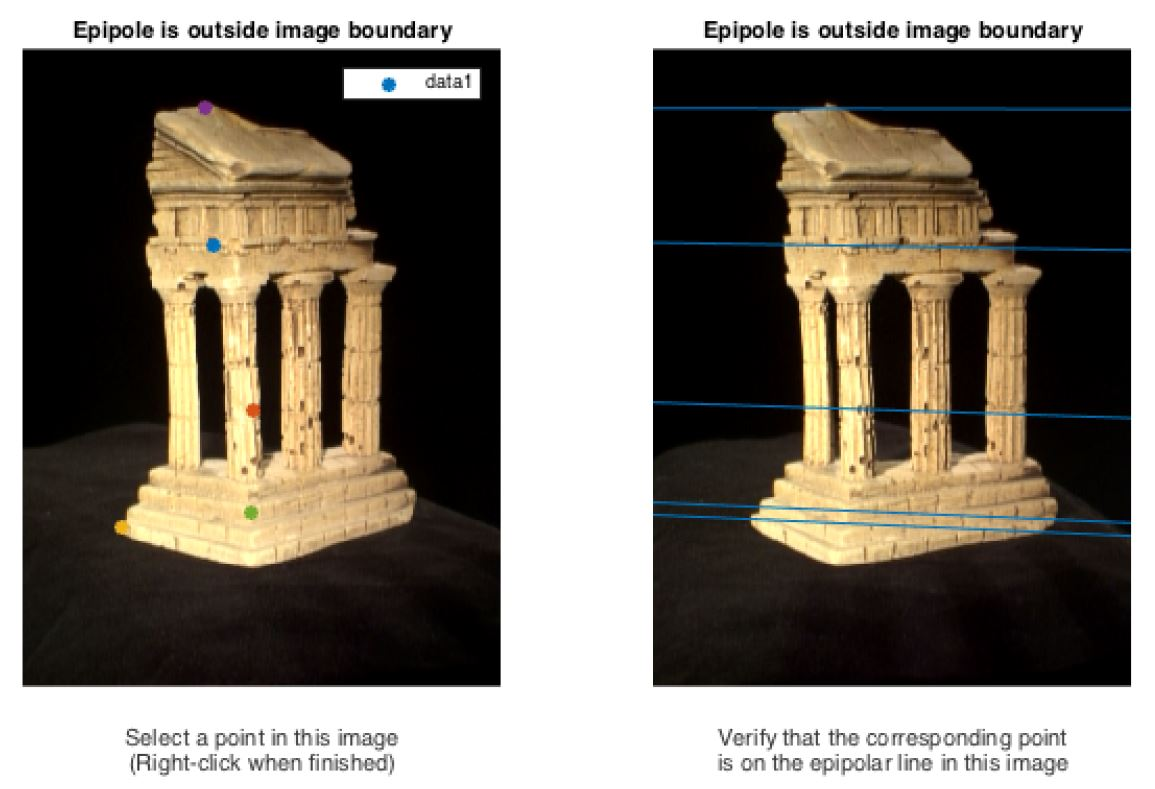

<center> Figure 1 - Epipolar lines visualization from "displayEpipolarF"

In [5]:
def eight_point(pts1, pts2, pmax):
    """
    Eight Point Algorithm
    [I] pts1, points in image 1 (Nx2 matrix)
        pts2, points in image 2 (Nx2 matrix)
        pmax, scalar value computed as max(H1,W1)
    [O] F, the fundamental matrix (3x3 matrix)
    """
    
    T = np.array([[1./pmax, 0,       0],
                  [0,       1./pmax, 0],
                  [0,       0,       1]])

    num_points = pts1.shape[0]

    # Convert 2D points to homogeneous coordinates
    hpts1 = np.concatenate([pts1, np.ones((num_points, 1))], axis=1)
    hpts2 = np.concatenate([pts2, np.ones((num_points, 1))], axis=1)

    # Normalize the homogeneous points
    hpts1_norm = (T @ hpts1.T).T
    hpts2_norm = (T @ hpts2.T).T

    # Construct the constraint matrix A
    x1_norm, y1_norm, _ = hpts1_norm.T
    x2_norm, y2_norm, _ = hpts2_norm.T

    A = np.vstack([
        x2_norm * x1_norm, x2_norm * y1_norm, x2_norm,
        y2_norm * x1_norm, y2_norm * y1_norm, y2_norm,
        x1_norm, y1_norm, np.ones(num_points)
    ]).T

    # solve for F
    _, _, Vt = np.linalg.svd(A)
    f = Vt[-1, :]
    F_norm = f.reshape(3, 3)

    # enforce the Rank-2 Constraint, a valid fundamental matrix must be of rank 2.
    F_norm_rank2 = _singularize(F_norm)

    # Refine the solution by local minimization
    pts1_norm_2d = pts1 / pmax
    pts2_norm_2d = pts2 / pmax
    F_refined = refineF(F_norm_rank2, pts1_norm_2d, pts2_norm_2d)

    # Un-normalize F
    F = T.T @ F_refined @ T
    
    # normalize the final F matrix by its last element (3,3)
    F = F / F[2, 2]

    return F

In [6]:
data = np.load("../data/some_corresp.npz")
print(data.files)


['pts1', 'pts2']


In [7]:
pts1 = data['pts1']
pts2 = data['pts2']
x_y_points_to_visualize = [(pts1[i, 0], pts1[i, 1]) for i in range(5)]
pmax = max(pts1.max(), pts2.max())
F = eight_point(pts1, pts2, pmax)
I1 = cv.imread("../data/im1.png")
I2 = cv.imread("../data/im2.png")
I1 = cv.cvtColor(I1, cv.COLOR_BGR2RGB)
I2 = cv.cvtColor(I2, cv.COLOR_BGR2RGB)


Optimization terminated successfully.
         Current function value: 0.000174
         Iterations: 8
         Function evaluations: 819


Use this axis to select points


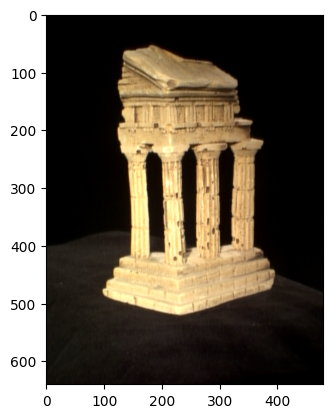

In [8]:
plt.imshow(I1)
print("Use this axis to select points")

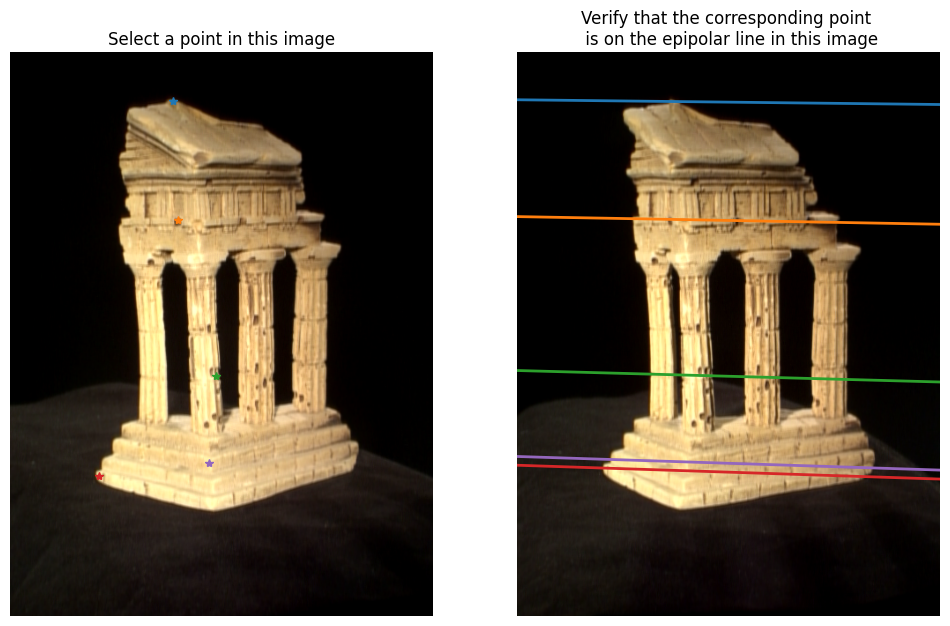

In [9]:
# Example usage of displayEpipolarF with two example points
displayEpipolarF(I1, I2, F, x_y_points=[(185, 55), (190, 190), (233, 367), (100, 480), (226, 466)])

#### 1.2 - Epipolar Correpondences
---
To reconstruct a 3D scene with a pair of two images, we need to find many point pairs. A point pair is two points (one in each image) that correspond to the same 3D scene point. With enough of these pairs, when we plot the resulting 3D points, we will have a rough outline of the 3D object. You found point pairs in HW3 using feature detectors and feature descriptors, and testing a point in one image with every single point in the other image. But here we can use the fundamental matrix to greatly simplify this search.

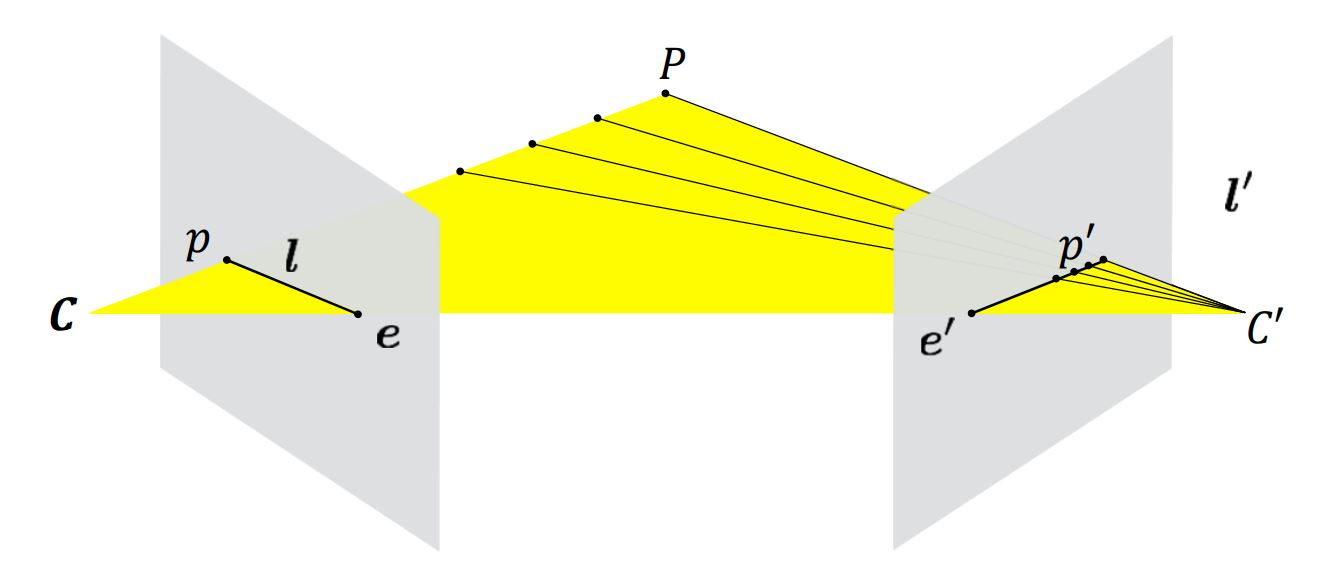
<center> Figure 2 - Epipolar Geometry. Potential matches for $p$ lie on the epipolar line $l'$.

Recall from class that given a point $p$ in one image (the left view in Figure 2). Its corresponding 3D scene point $P$ could lie anywhere along the line from the camera center $C$ to the point $p$. This line, along with a second image's camera center $C'$ (the right view in Figure 2) forms a plane. This plane intersects with the image plane of the second camera, resulting in a line $l'$ in the second image which describes all the possible locations that $p$ may be found in the second image. Line $l'$ is the epipolar line, and we only need to search along this line to find a match for point $p$ found in the first image.

* Write the following function:

In [10]:
def epipolar_correspondences(I1, I2, F, pts1):
    """
    Epipolar Correspondences
    [I] I1, image 1 (H1xW1 matrix)
        I2, image 2 (H2xW2 matrix)
        F, fundamental matrix from image 1 to image 2 (3x3 matrix)
        pts1, points in image 1 (Nx2 matrix)
    [O] pts2, points in image 2 (Nx2 matrix)
    """
    
    H1, W1 = I1.shape[:2]
    H2, W2 = I2.shape[:2]

    I1_gray = cv.cvtColor(I1, cv.COLOR_RGB2GRAY).astype(np.float32)
    I2_gray = cv.cvtColor(I2, cv.COLOR_RGB2GRAY).astype(np.float32)

    # --- Parameters for Matching ---
    # Window size for patch comparison 
    window_size = 15
    half_window = window_size // 2
    
    pts2 = []

    for p1 in pts1:
        # Convert point to integer for indexing
        p1x, p1y = int(round(p1[0])), int(round(p1[1]))

        # Check if the window around p1 is within the bounds of I1
        if not (half_window <= p1y < H1 - half_window and 
                half_window <= p1x < W1 - half_window):
            # If p1 is too close to the border, we can't get a valid patch.
            # Append a default point and continue.
            pts2.append([0, 0])
            continue

        # Extract the patch from I1 around p1
        patch1 = I1_gray[p1y - half_window : p1y + half_window + 1,
                         p1x - half_window : p1x + half_window + 1]

        # 2. Calculate the epipolar line in I2
        p1_h = np.array([p1[0], p1[1], 1]).T
        l2 = F @ p1_h
        a, b, c = l2

        # Generate candidate points along the epipolar line in I2
        # To be robust, we iterate along the axis where the line is "less steep" to ensure we don't miss pixels.
        if abs(a) < abs(b): # Line is more horizontal
            x_coords = np.arange(W2)
            y_coords = np.round((-a * x_coords - c) / b).astype(int)
            
            valid_indices = (y_coords >= half_window) & (y_coords < H2 - half_window) & \
                            (x_coords >= half_window) & (x_coords < W2 - half_window)

        else:
            y_coords = np.arange(H2)
            x_coords = np.round((-b * y_coords - c) / a).astype(int)

            valid_indices = (x_coords >= half_window) & (x_coords < W2 - half_window) & \
                            (y_coords >= half_window) & (y_coords < H2 - half_window)
        # Filter out points that are outside the image or too close to the border
        x_candidates = x_coords[valid_indices]
        y_candidates = y_coords[valid_indices]

        if len(x_candidates) == 0:
            # No valid candidates found on the epipolar line within image bounds
            pts2.append([0, 0])
            continue

        # Find the best match using SSD
        min_ssd = float('inf')
        best_p2 = None

        for x, y in zip(x_candidates, y_candidates):
            # Extract patch2 from I2
            patch2 = I2_gray[y - half_window : y + half_window + 1,
                             x - half_window : x + half_window + 1]
            
            # Calculate Sum of Squared Differences
            ssd = np.sum((patch1 - patch2) ** 2)
            
            if ssd < min_ssd:
                min_ssd = ssd
                best_p2 = [x, y]
        
        if best_p2 is not None:
            pts2.append(best_p2)
        else:
            pts2.append([0, 0]) # Should not happen if candidates were found

    return np.array(pts2)

where `I1` and `I2` are two-view images, `F` is the fundamental matrix computed for the two images using your `eight_point` function, `pts1` is a $N \times 2$ matrix containing the $(x,y)$ points in the first image, and the function should return `pts2`, a $N \times 2$ matrix, which contains the corresponding points in the second image. Implementation tips:

* To match one point $p$ in image 1, use the fundamental matrix to estimate the corresponding epipolar line $l'$ and generate a set of candidate points in the second image.

* For each candidate points $p'$, a similarity score between $p$ and $p'$ is computed. The point among candidates with highest score is treated as epipolar correspondence.

* There are many ways to define the similarity between two points. Feel free to use whatever you want and **describe it in your write-up**. One possible solution is to select a small window of size $w$ around the point $p$. Then compare this target window to the window of the candidate point in the second image. For the images we gave you, simple Euclidean distance or Manhattan distance should suffice.

* Remember to take care of data type and index range. You can use the provided function `epipolarMatchGUI` to visually test your function. Your function does not need to be perfect, but it should get most easy points correct, like corners, dots etc.

* Please include a screenshot of `epipolarMatchGUI` running with your implementation of `epipolar_correspondences` (similar to Figure 3). Mention the similarity metric you decided to use. Also comment on any cases where your matching algorithm consistently fails, and why you might think this is.

* Visualization function:

In [11]:
# helper function 4: Uses F, and the matching function to draw the epipolar correpondences on the epipolar lines
def epipolarMatchVis(I1, I2, F, x_y_points):
    assert len(x_y_points[0]) == 2, "x_y_points must be a list of tuples of size 2"
    e1, e2 = _epipoles(F)

    sy, sx, sd = I2.shape

    f, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 9))
    ax1.imshow(I1)
    ax1.set_title('Select a point in this image')
    ax1.set_axis_off()
    ax2.imshow(I2)
    ax2.set_title('Verify that the corresponding point \n is on the epipolar line in this image')
    ax2.set_axis_off()

    for x, y in x_y_points:
        plt.sca(ax1)

        xc, yc = int(x), int(y)
        v = np.array([[xc], [yc], [1]])

        l = F @ v
        s = np.sqrt(l[0]**2+l[1]**2)

        if s==0:
            error('Zero line vector in displayEpipolar')

        l = l / s
        if l[0] != 0:
            xs = 0
            xe = sx - 1
            ys = -(l[0] * xs + l[2]) / l[1]
            ye = -(l[0] * xe + l[2]) / l[1]
        else:
            ys = 0
            ye = sy - 1
            xs = -(l[1] * ys + l[2]) / l[0]
            xe = -(l[1] * ye + l[2]) / l[0]

        ax1.plot(x, y, '*', markersize=6, linewidth=2)
        ax2.plot([xs, xe], [ys, ye], linewidth=2)

        # draw points
        pc = np.array([[xc, yc]])
        p2 = epipolar_correspondences(I1, I2, F, pc)
        ax2.plot(p2[0,0], p2[0,1], 'ro', markersize=8, linewidth=2)
        plt.draw()

* Example result:

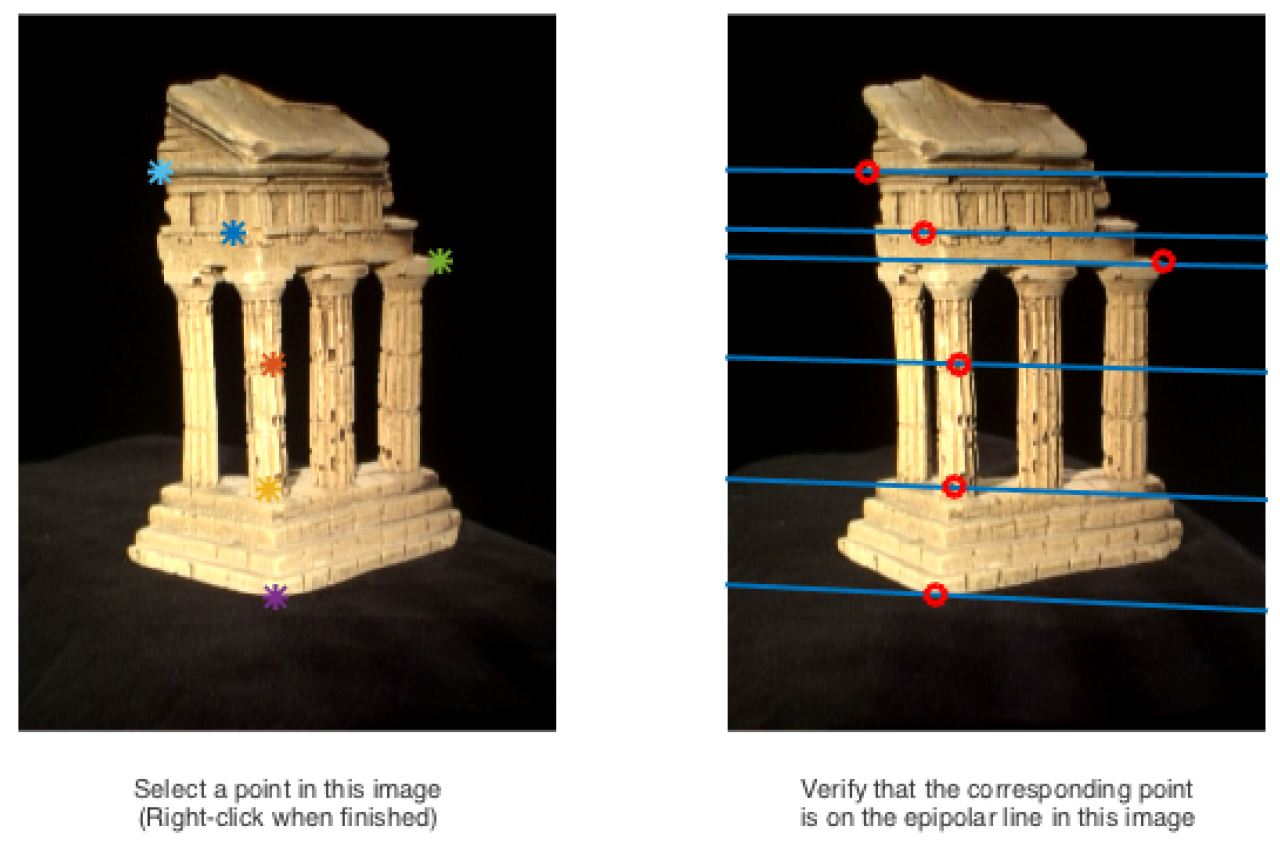
<center> Figure 3 - Epipolar Match visualization. A few errors are alright, but it should get most easy points correct (corners, dots, etc.)

In [12]:
im1 = I1.copy()
im2 = I2.copy()

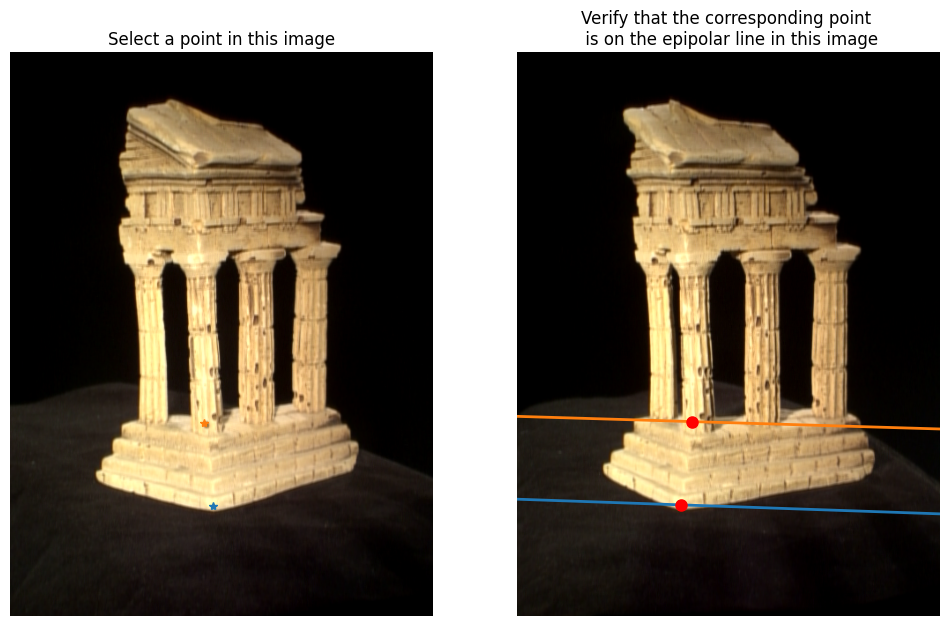

In [13]:
# Example usage of epipolarMatchVis with two example points
epipolarMatchVis(im1, im2, F, x_y_points=[(230, 515), (220, 420)])

#### 1.3 - Essential Matrix
---
In order to get the full camera projection matrices we need to compute the Essential matrix. So far, we have only been using the Fundamental matrix.

* Write the following function:

In [14]:
def essential_matrix(F, K1, K2):
    """
    Essential Matrix
    [I] F, the fundamental matrix (3x3 matrix)
        K1, camera matrix 1 (3x3 matrix)
        K2, camera matrix 2 (3x3 matrix)
    [O] E, the essential matrix (3x3 matrix)
    """
    E = K2.T @ F @ K1
    return E

In [15]:
intrinsics = np.load('../data/intrinsics.npz')
K1 = intrinsics['K1']
K2 = intrinsics['K2']
E = essential_matrix(F, K1, K2)
print("Essential Matrix E:")
print(E)

Essential Matrix E:
[[  -1.34574426   29.07118462    7.75265911]
 [  68.88731584   -0.54273929 -370.14770947]
 [   1.17198847  374.71223603    0.4291653 ]]


Where `F` is the Fundamental matrix computed between two images, `K1` and `K2` are the intrinsic camera matrices for the first and second image respectively (contained in `data/intrinsics.npz`), and `E` is the computed essential matrix. The intrinsic camera parameters are typically acquired through camera calibration. Refer to the class slides for the
relationship between the Fundamental matrix and the Essential matrix.

* Please include your estimated $E$ matrix for the temple image pair in the PDF report.

#### 1.4 - Triangulation
---
Write a function to triangulate pairs of 2D points in the images to a set of 3D points.

* Write the following function:

Where `pts1` and `pts2` are the $N\times 2$ matrices with the 2D image coordinates, `M1` and `M2` are the $3\times4$ camera projection matrices and `pts3d` is an $N\times 3$ matrix with the corresponding 3D points (in all cases, one point per row). Remember that you will need to multiply the given intrinsic matrices with your solution for the extrinsic camera matrices to obtain the final camera projection matrices. 

* For `M1` you can assume no rotation or translation, so the extrinsic matrix is just $\left[I \lvert 0\right]$. 

* For `M2`, pass the essential matrix to the provided function `camera2` to get four possible **extrinsic** matrices. You will need to determine which of these is the correct one to use. Refer to the class slides to remind yourself of the 4 possible camera layouts. The correct configuration is the one for which most of the 3D points are in front of both cameras (i.e. have a positive depth), and make up a reasonable recovered shape. To make sure you choose the right one, write a helper function that apply the extrinsics of camera 2 to the recovered 3D points and check that they are still in front of camera 1 (positive $Z$).

* Keep in mind to multiply the extrinsics matrices by the corresponding intrinsics before inputting them to `triangulate`.
* Once implemented, check the performance by looking at the re-projection error. To compute the re-projection error, project the estimated 3D points back to the image 1 and compute the mean Euclidean error between projected 2D points and the given `pts1`.

* **In your write-up**: Describe how you determined which extrinsic matrix is correct. Note that simply rewording the hint is not enough. Report your re-projection error using the given `pts1` and `pts2` in `data/some_corresp.npz`. If implemented correctly, the re-projection error should be less than 2 pixels.

* Helper functions:

In [16]:
# helper function 5: returns the 4 options for camera matrix M2 given the essential matrix
def camera2(E):
    U,S,V = np.linalg.svd(E)
    m = S[:2].mean()
    E = U.dot(np.array([[m,0,0], [0,m,0], [0,0,0]])).dot(V)
    U,S,V = np.linalg.svd(E)
    W = np.array([[0,-1,0], [1,0,0], [0,0,1]])

    if np.linalg.det(U.dot(W).dot(V))<0:
        W = -W

    M2s = np.zeros([3,4,4])
    M2s[:,:,0] = np.concatenate([U.dot(W).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
    M2s[:,:,1] = np.concatenate([U.dot(W).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
    M2s[:,:,2] = np.concatenate([U.dot(W.T).dot(V), U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)
    M2s[:,:,3] = np.concatenate([U.dot(W.T).dot(V), -U[:,2].reshape([-1, 1])/abs(U[:,2]).max()], axis=1)

    return M2s

In [17]:
def triangulate(M1, pts1, M2, pts2):
    """
    Triangulation
    [I] M1, camera projection matrix 1 (3x4 matrix)
        pts1, points in image 1 (Nx2 matrix)
        M2, camera projection matrix 2 (3x4 matrix)
        pts2, points in image 2 (Nx2 matrix)
    [O] pts3d, 3D points in space (Nx3 matrix)
    """
    num_points = pts1.shape[0]
    pts3d = np.zeros((num_points, 3))

    for i in range(num_points):
        p1 = pts1[i, :]
        p2 = pts2[i, :]
        
        A = np.array([
            p1[0] * M1[2, :] - M1[0, :],
            p1[1] * M1[2, :] - M1[1, :],
            p2[0] * M2[2, :] - M2[0, :],
            p2[1] * M2[2, :] - M2[1, :]
        ])
        
        _, _, Vt = np.linalg.svd(A)
        P_homo = Vt[-1, :]
        
        # Convert from homogeneous to 3D coordinates by dividing by the last element
        pts3d[i, :] = P_homo[:3] / P_homo[3]
        
    return pts3d

In [18]:
def find_best_m2_and_triangulate(E, K1, K2, pts1, pts2):
    """
    Finds the correct M2 and triangulates points.
    """
    # Set the first camera matrix M1
    M1_ext = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
    M1 = K1 @ M1_ext

    # Get the four possible extrinsic matrices for the second camera
    M2_ext_options = camera2(E)
    
    best_M2 = None
    max_in_front_count = -1
    final_pts3d = None

    for i in range(M2_ext_options.shape[2]):
        # Get a candidate M2
        M2_ext_candidate = M2_ext_options[:, :, i]
        M2_candidate = K2 @ M2_ext_candidate
        
        # Triangulate points with the candidate M2
        pts3d_candidate = triangulate(M1, pts1, M2_candidate, pts2)
        
        # Cheirality check: count how many points are in front of both cameras
        in_front_count = 0
        
        # Get R and t from the extrinsic matrix for the second camera check
        R = M2_ext_candidate[:, :3]
        t = M2_ext_candidate[:, 3]
        
        for P in pts3d_candidate:
            # Check for camera 1 (depth must be positive in world frame)
            z1 = P[2]
            
            # Check for camera 2 (depth must be positive in camera 2's frame)
            P_cam2 = R.T @ P + t # Note: Standard formulation is P_cam = R(P_world - C), where t=-RC. This is an equivalent check.
            # A more direct way from [R|t] is checking the z-component of R@P+t
            P_prime = R @ P + t # P' is P in camera 2 coordinates
            z2 = P_prime[2]

            if z1 > 0 and z2 > 0:
                in_front_count += 1
        
        # If this candidate is better than the previous best, update
        if in_front_count > max_in_front_count:
            max_in_front_count = in_front_count
            best_M2 = M2_candidate
            final_pts3d = pts3d_candidate

    return best_M2, final_pts3d

#### 1.5 - Putting It All Together
---
You now have all the pieces you need to generate a full 3D reconstruction. Write a test script `test_temple_coords` that does the following:

* Load the two images and the point correspondences from `data/some_corresp.npz`.
* Run eight point to compute the fundamental matrix `F`.
* Load the points in image 1 contained in `data/temple_coords.npz` and run your `epipolar_correspondences` on them to get the corresponding points in image 2.
* Load `data/intrinsics.npz` and compute the essential matrix `E`.
* Compute the first camera projection matrix `M1` and use `camera2` to compute the four candidates for `M2`.
* Run your `triangulate` function using the four sets of camera matrix candidates (after scaling with the intrinsics), the points from `data/temple_coords.npz`, and their computed correspondences.
* Figure out the correct `M2` and the corresponding 3D points.
* Use matplotlib's scatter function to plot these point correspondences on screen.
* Report your computed extrinsic parameters (`R1`,`R2`,`t1`,`t2`) in your PDF.
* We will use your test script to run your code, so be sure it runs smoothly. In particular, use relative paths to load files, not absolute paths.
* **In your write-up**: Include 3 images of your final reconstruction of the points given in the file `data/temple_coords.npz`, from different angles as shown in Figure 4.

* Example result:

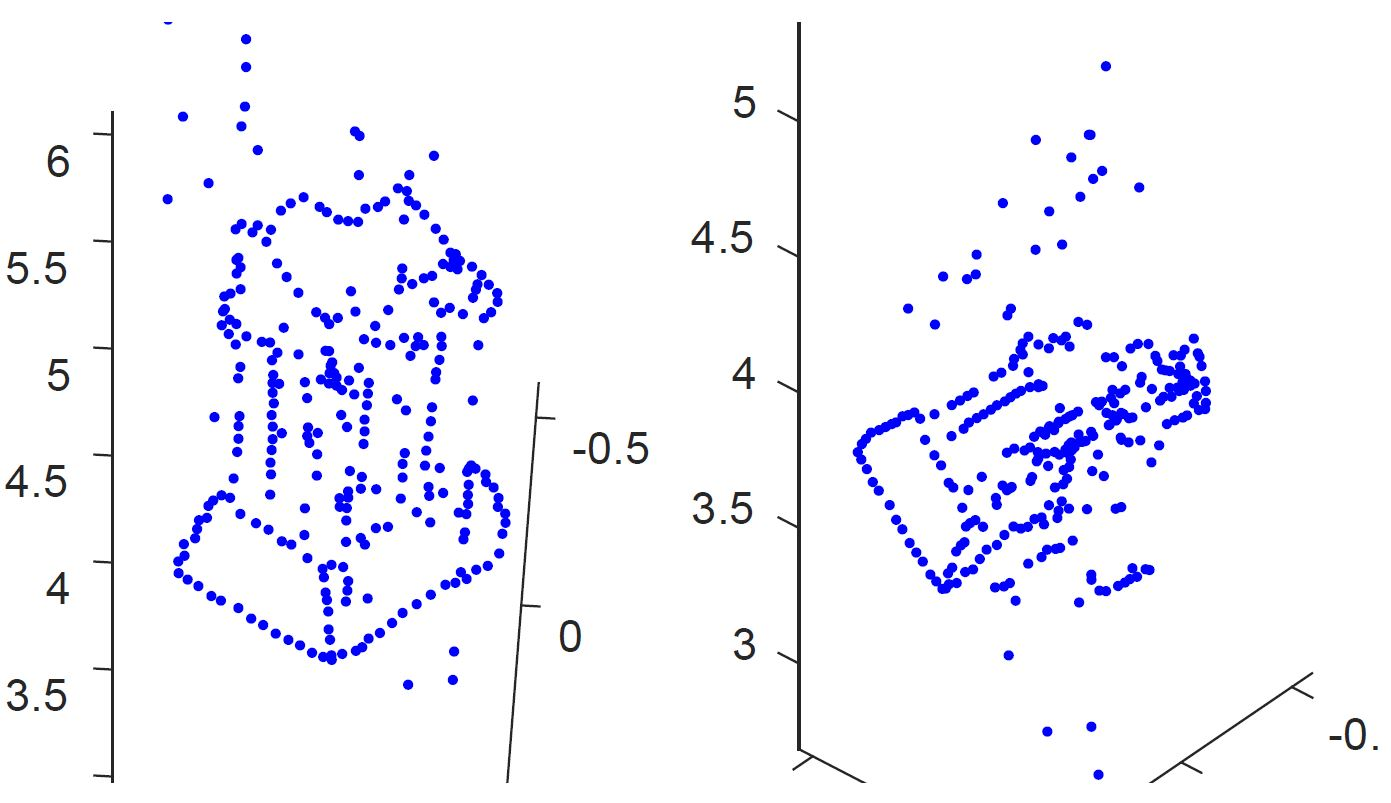
<center> Figure 4 - Sample Reconstructions.

In [19]:
def plot_reconstruction(pts3d, title, elev, azim, point_size=15, show_axes=True):
    """
    Plots the 3D reconstruction with automatic zoom and optional clean aesthetics.
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(pts3d[:, 0], pts3d[:, 1], pts3d[:, 2], c='b', marker='o', s=point_size, depthshade=True)
    
    # --- Automatic Zoom Logic ---
    # Find the bounding box of the data and center the plot
    max_range = np.array([pts3d[:, 0].max() - pts3d[:, 0].min(),
                          pts3d[:, 1].max() - pts3d[:, 1].min(),
                          pts3d[:, 2].max() - pts3d[:, 2].min()]).max() / 2.0
    
    mid_x = (pts3d[:, 0].max() + pts3d[:, 0].min()) * 0.5
    mid_y = (pts3d[:, 1].max() + pts3d[:, 1].min()) * 0.5
    mid_z = (pts3d[:, 2].max() + pts3d[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.set_title(title, fontsize=16)
    ax.view_init(elev=elev, azim=azim)
    
    if show_axes:
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
    else:
        # Hide grid, panes, and axis labels for a clean look
        ax.set_axis_off()
        
    plt.show()

Step 1: Loading data
Step 2: Computing Fundamental Matrix F
Optimization terminated successfully.
         Current function value: 0.000107
         Iterations: 8
         Function evaluations: 808
Step 3: Finding epipolar correspondences for temple points
Step 4: Computing Essential Matrix E...
Step 5: Finding the correct camera matrix M2
Found best M2 with 288 points in front of both cameras.

--- Computed Extrinsic Parameters ---
R1 (Rotation of Camera 1):
 [[1 0 0]
 [0 1 0]
 [0 0 1]]

t1 (Translation of Camera 1):
 [0 0 0]

R2 (Rotation of Camera 2):
 [[ 0.9656441  -0.0240544   0.25875252]
 [ 0.02357884  0.99970977  0.00494161]
 [-0.25879629  0.00132924  0.96593101]]

t2 (Translation of Camera 2):
 [-1.         -0.02044277  0.07758157]
-------------------------------------

Step 6: Plotting the 3D reconstruction...


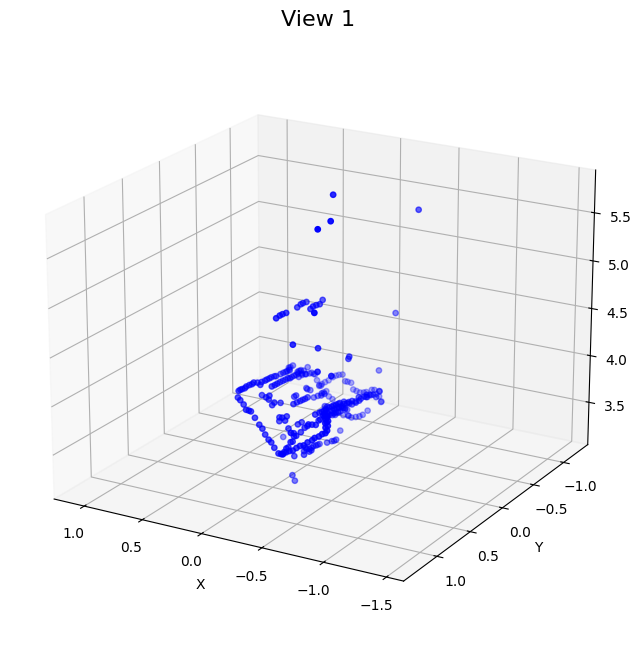

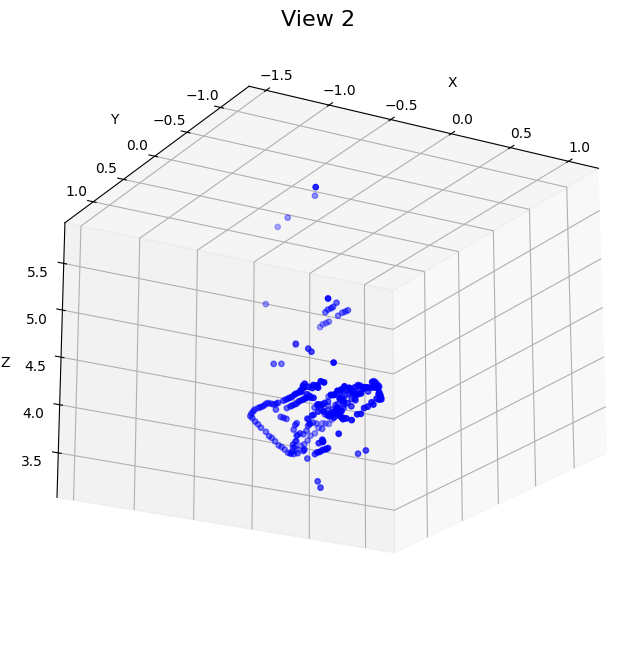

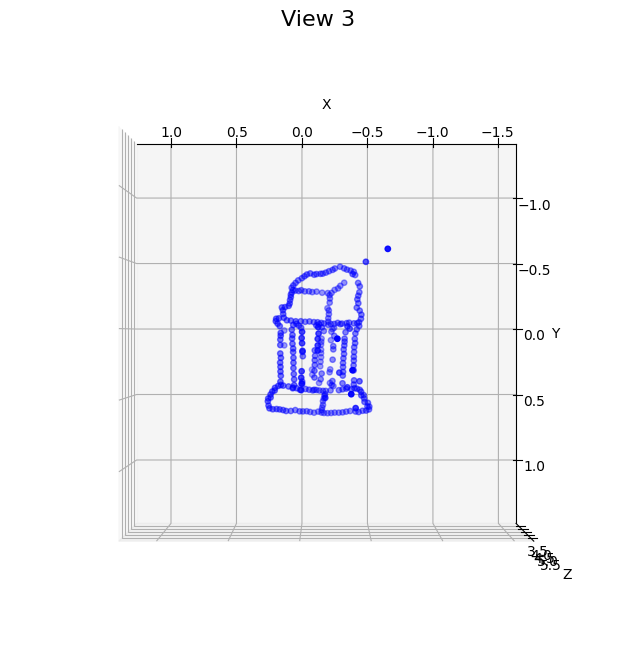

In [20]:
print("Step 1: Loading data")
im1 = cv.imread('../data/im1.png')
im2 = cv.imread('../data/im2.png')
corresp_data = np.load('../data/some_corresp.npz')
pts1 = corresp_data['pts1']
pts2 = corresp_data['pts2']
temple_coords_data = np.load('../data/temple_coords.npz')
temple_pts1 = temple_coords_data['pts1']
intrinsics = np.load('../data/intrinsics.npz')
K1, K2 = intrinsics['K1'], intrinsics['K2']

print("Step 2: Computing Fundamental Matrix F")
pmax = float(max(im1.shape[:2]))
F = eight_point(pts1, pts2, pmax)

print("Step 3: Finding epipolar correspondences for temple points")
temple_pts2 = epipolar_correspondences(im1, im2, F, temple_pts1)

print("Step 4: Computing Essential Matrix E...")
E = essential_matrix(F, K1, K2)

print("Step 5: Finding the correct camera matrix M2")
M1_ext = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
M1 = K1 @ M1_ext
M2_ext_options = camera2(E)

best_M2_ext = None
final_pts3d = None
max_in_front_count = -1

for i in range(M2_ext_options.shape[2]):
    M2_ext_candidate = M2_ext_options[:, :, i]
    M2_candidate = K2 @ M2_ext_candidate
    pts3d_candidate = triangulate(M1, temple_pts1, M2_candidate, temple_pts2)
    
    in_front_count = 0
    R, t = M2_ext_candidate[:, :3], M2_ext_candidate[:, 3]
    for P in pts3d_candidate:
        z1 = P[2]
        z2 = (R @ P + t)[2]
        if z1 > 0 and z2 > 0:
            in_front_count += 1
    
    if in_front_count > max_in_front_count:
        max_in_front_count = in_front_count
        best_M2_ext = M2_ext_candidate
        final_pts3d = pts3d_candidate

print(f"Found best M2 with {max_in_front_count} points in front of both cameras.")

# 6. Report the computed extrinsic parameters
print("\n--- Computed Extrinsic Parameters ---")
R1, t1 = M1_ext[:, :3], M1_ext[:, 3]
R2, t2 = best_M2_ext[:, :3], best_M2_ext[:, 3]
print("R1 (Rotation of Camera 1):\n", R1)
print("\nt1 (Translation of Camera 1):\n", t1)
print("\nR2 (Rotation of Camera 2):\n", R2)
print("\nt2 (Translation of Camera 2):\n", t2)
print("-------------------------------------")

# 7. Visualize the 3D reconstruction
print("\nStep 6: Plotting the 3D reconstruction...")
plot_reconstruction(final_pts3d, "View 1", elev=20, azim=120)
plot_reconstruction(final_pts3d, "View 2", elev=-20, azim=-120)
plot_reconstruction(final_pts3d, "View 3", elev=90, azim=90)

plt.show()

### <img src="https://img.icons8.com/external-ddara-lineal-ddara/64/000000/external-yoga-pose-yoga-poses-ddara-lineal-ddara-36.png" style="height:50px;display:inline"> Part 2 - Pose Estimation 
---
In this section, you will implement what you have learned in class to estimate the intrinsic and extrinsic parameters of camera given 2D points $p$ on image and their corresponding 3D points $P$. In other words, given a set of matched points $\left\{P_i ,p_i\right\}$ and camera model (in homogeneous coordinates):

$$ p = M P$$

we want to find the estimate of the camera matrix $M\in \mathbb{R}^{3\times4}$, as well as intrinsic parameter
matrix $K\in \mathbb{R}^{3\times3}$, camera rotation $R\in \mathbb{R}^{3\times3}$ and camera translation $t\in \mathbb{R}^{3\times1}$, such that:
$$ M = K \left[R \lvert t\right] $$

#### 2.1 - Estimating $M$
---
* Write a function that estimates the camera matrix $M$ given 2D and 3D points $p,P$.

In [21]:
def estimate_pose(p, P):
    """
    Camera Matrix Estimation
    [I] p, 2D points (Nx2 matrix)
        P, 3D points (Nx3 matrix)
    [O] M, camera matrix (3x4 matrix)
    """
    num_points = p.shape[0]

    # Convert 3D points to homogeneous coordinates by adding a column of ones
    P_h = np.hstack((P, np.ones((num_points, 1))))
    
    # Construct the matrix A for the linear system Am = 0    A = []
    for i in range(num_points):
        x_i, y_i = p[i, 0], p[i, 1]
        P_h_i = P_h[i, :]
        
        # First row corresponding to the x-coordinate constraint
        row1 = np.concatenate([
            np.zeros(4),
            -P_h_i,
            y_i * P_h_i
        ])
        
        # Second row corresponding to the y-coordinate constraint
        row2 = np.concatenate([
            P_h_i,
            np.zeros(4),
            -x_i * P_h_i
        ])
        
        A.append(row1)
        A.append(row2)
        
    A = np.array(A)  # Shape will be (2*N, 12)
    
    U, S, Vt = np.linalg.svd(A)
    m = Vt[-1, :]
    
    # Reshape the 12x1 vector m back into the 3x4 camera matrix M
    M = m.reshape(3, 4)
    
    return M

where `p` is $2\times N$ matrix denoting the $(x, y)$ coordinates of the $N$ points on the image plane and `P` is $3\times N$ matrix denoting the $(x,y,z)$ coordinates of the corresponding points in the 3D world. Recall that this camera matrix can be computed using the same strategy as homography estimation by Direct Linear Transform (DLT).

* Once you finish this function, you can run the following script to test your implementation:

In [22]:
# 1. Generate random camera matrix
K = np.array([[1,0,100], [0,1,100], [0,0,1]])
R, _,_ = la.svd(np.random.randn(3,3))
if la.det(R) < 0: R = -R
t = np.vstack((np.random.randn(2,1), 1))
M = K @ np.hstack((R, t))

# 2. Generate random 2D and 3D points
N = 100
P = np.random.randn(N,3)
p = M @ np.hstack((P, np.ones((N,1)))).T
p = p[:2,:].T / np.vstack((p[2,:], p[2,:])).T

# 3. Test pose estimation with clean points
Mc = estimate_pose(p, P)
pp = Mc @ np.hstack((P, np.ones((N,1)))).T
pp = pp[:2,:].T / np.vstack((pp[2,:], pp[2,:])).T

print('Reprojection Error with clean 2D points:', la.norm(p-pp))
print('Pose Error with clean 2D points:', la.norm((Mc/Mc[-1,-1])-(M/M[-1,-1])))

# 4. Test pose estimation with noisy points
p = p + np.random.rand(p.shape[0], p.shape[1])
Mn = estimate_pose(p, P)
pp = Mn @ np.hstack((P, np.ones((N,1)))).T
pp = pp[:2,:].T / np.vstack((pp[2,:], pp[2,:])).T

print('Reprojection Error with noisy 2D points:', la.norm(p-pp))
print('Pose Error with noisy 2D points:', la.norm((Mn/Mn[-1,-1])-(M/M[-1,-1])))

UnboundLocalError: cannot access local variable 'A' where it is not associated with a value

* **In your write-up**: Please include the output of this script in your PDF.

#### 2.2 - Intrinsic/Extrinsic Parameters
---
* Write a function that estimates both intrinsic and extrinsic parameters from a camera matrix:

In [ ]:
from scipy.linalg import rq

def estimate_params(M):
    """
    Camera Parameter Estimation
    [I] M, camera matrix (3x4 matrix)
    [O] K, camera intrinsics (3x3 matrix)
        R, camera extrinsics rotation (3x3 matrix)
        t, camera extrinsics translation (3x1 matrix)
    """
    if np.linalg.det(M[:, :3]) < 0:
        M = -M
    # Compute the camera center c 
    U, S, Vt = np.linalg.svd(M)
    c_homo = Vt[-1, :]  # Homogeneous coordinates of the camera center
    c = c_homo[:3] / c_homo[3]

    # Compute intrinsic K and rotation R using RQ decomposition
    M_sub = M[:, :3]
    
    # scipy.linalg.rq provides the RQ decomposition.
    # It decomposes M_sub into an upper-triangular matrix (K) and an orthonormal matrix (R).
    K, R = rq(M_sub)

    # The decomposition is not unique. The diagonal elements of K must be positive
    # as they represent focal lengths. We create a sign correction matrix T.
    T = np.diag(np.sign(np.diag(K)))
    
    # If the determinant of R is -1, it's a reflection, not a rotation.
    # flipping the sign of one axis in T will correct this.
    if np.linalg.det(R) < 0:
        T[2, 2] *= -1

    # Apply the correction to K and R
    K = K @ T
    R = T @ R # T is its own inverse since T*T = I
    
    # Normalize K so that K[2, 2] = 1
    K = K / K[2, 2]

    # --- 3. Compute the translation t ---
    t = -R @ c
    t = t.reshape(3, 1) # Ensure t is a column vector

    return K, R, t

From what we learned on class, the `estimate_params` function should consecutively run the following steps:
* Compute the camera center $c$ by using SVD. Hint: $c$ is the eigenvector corresponding to the smallest eigenvalue.
* Compute the intrinsic $K$ and rotation $R$ by using QR decomposition. $K$ is a right upper triangle matrix while $R$ is an orthonormal matrix.
* Compute the translation by $t = -Rc$.

* Once you finish this function, you can run the following script to test your implementation:

In [ ]:
# 1. Generate random camera matrix
K = np.array([[1,0,100], [0,1,100], [0,0,1]])
R, _,_ = la.svd(np.random.randn(3,3))
if la.det(R) < 0: R = -R
t = np.vstack((np.random.randn(2,1), 1))
M = K @ np.hstack((R, t))

# 2. Generate random 2D and 3D points
N = 100
P = np.random.randn(N,3)
p = M @ np.hstack((P, np.ones((N,1)))).T
p = p[:2,:].T / np.vstack((p[2,:], p[2,:])).T

# 3. Test parameter estimation with clean points
Mc = estimate_pose(p, P)
Kc, Rc, tc = estimate_params(Mc)

print('Intrinsic Error with clean 2D points:', la.norm((Kc/Kc[-1,-1])-(K/K[-1,-1])))
print('Rotation Error with clean 2D points:', la.norm(R-Rc))
print('Translation Error with clean 2D points:', la.norm(t-tc))

# 4. Test parameter estimation with noisy points
p = p + np.random.rand(p.shape[0], p.shape[1])
Mn = estimate_pose(p, P)
Kn, Rn, tn = estimate_params(Mn)

print('Intrinsic Error with noisy 2D points:', la.norm((Kn/Kn[-1,-1])-(K/K[-1,-1])))
print('Rotation Error with noisy 2D points:', la.norm(R-Rn))
print('Translation Error with noisy 2D points:', la.norm(t-tn))

Intrinsic Error with clean 2D points: 4.2399509327232445e-12
Rotation Error with clean 2D points: 5.948983884293022e-13
Translation Error with clean 2D points: 7.139906812470913e-12
Intrinsic Error with noisy 2D points: 0.7039220373958758
Rotation Error with noisy 2D points: 0.04655592525967026
Translation Error with noisy 2D points: 0.022330223018736876


* **In your write-up**: Please include the output of this script in your PDF.

#### 2.3 - Visualizing Projection of a CAD Model
---

In this section, you will use your implementations of `estimate_pose` and `estimate_params` to visualize the camera pose estimated from a real image and a 3D CAD model.

We provide a script that:
1. Loads a real image, a CAD model, and corresponding 2D/3D keypoints
2. Estimates the camera matrix \( M \), intrinsics \( K \), rotation \( R \), and translation \( t \)
3. Projects both the annotated 3D keypoints and the entire CAD model back onto the image
4. Displays three plots:
    - The input image with 2D keypoints and projected 3D points
    - The CAD model visualized in 3D, rotated using your estimated rotation matrix
    - The CAD model projected back onto the image using your estimated camera matrix

---

### 🎨 Color Coding (used in visualization):

- 🟢 **Green circles** — Given 2D keypoints (annotated in the image)
- ⚫ **Black dots** — Projected 3D keypoints (via your camera matrix)
- 🔵 **Blue surface** — 3D CAD model after applying your estimated rotation matrix \( R \)
- 🔴 **Red wireframe** — CAD model projected onto the image using your estimated camera matrix

---

> 📌 **Instructions**:  
> Run the provided cell below to generate the visualizations.  
> You do not need to write code here — your `estimate_pose` and `estimate_params` implementations from earlier will be used.

> 📝 **In your write-up**:  
> Include screenshots of all **three subplots** in your PDF.  
> Describe whether the projection looks accurate and how well the CAD model aligns with the image.

> ⚠️ **Important**: You must use the provided visualization script with the provided colors.


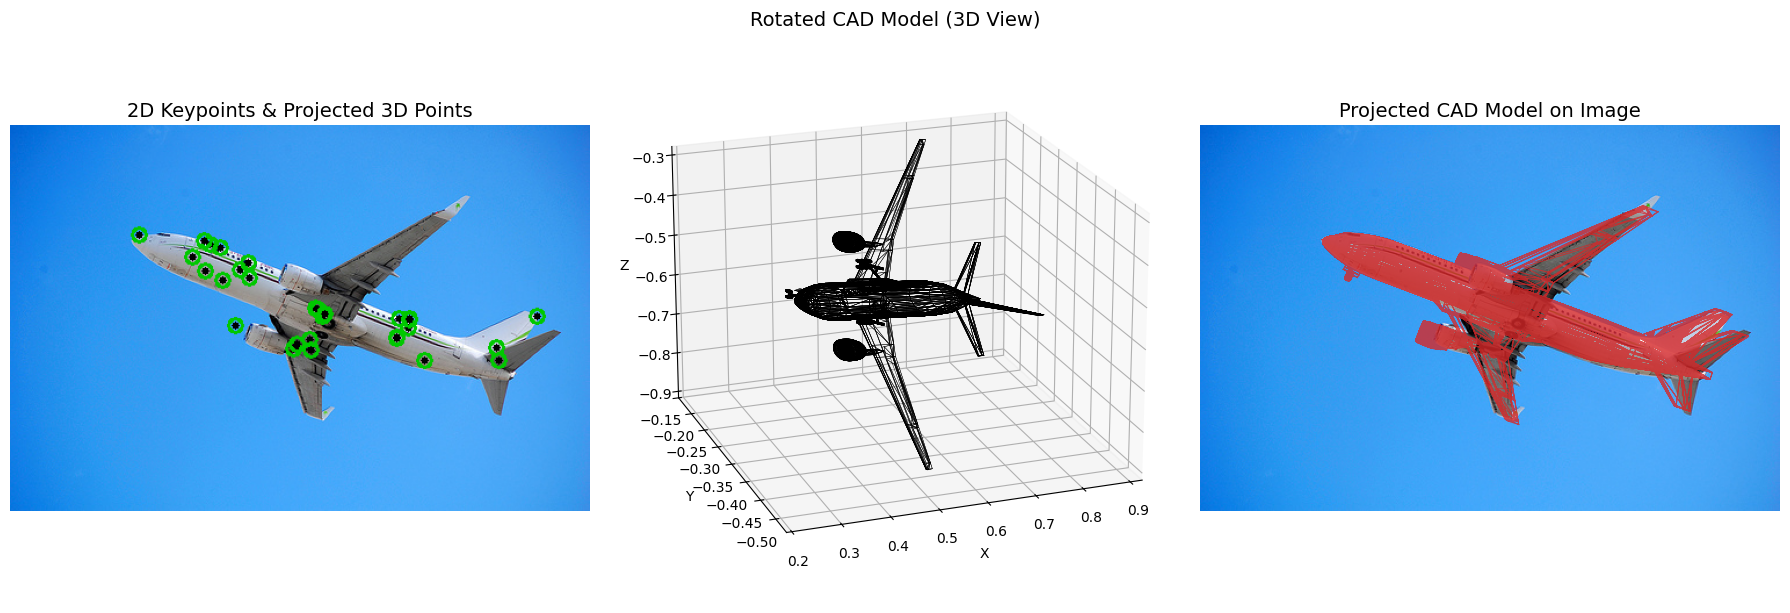

In [ ]:

def project_cad_to_2d():
    data = np.load('../data/pnp.npz', allow_pickle=True)
    image = data['image']
    cad = data['cad'][0][0]
    pts2d = data['x']
    pts3d = data['X']
    
    vertices = cad[0]
    triangles = cad[1] - 1
    
    # Estimate camera matrix and parameters
    M = estimate_pose(pts2d, pts3d)
    K, R, t = estimate_params(M)

    # Project the given 3D points
    pts3d_h = np.hstack((pts3d, np.ones((pts3d.shape[0], 1)))).T  # 4xN
    projected_pts2d = (M @ pts3d_h)
    projected_pts2d = projected_pts2d[:2] / projected_pts2d[2]
    projected_pts2d = projected_pts2d.T  # Nx2

    # Create a copy of the image for drawing
    img_with_points = image.copy()
    for i in range(len(pts2d)):
        img_with_points = cv.circle(img_with_points, (int(pts2d[i,0]), int(pts2d[i,1])), radius=6, color=(0, 200, 0), thickness=2)  # bright green
        img_with_points = cv.circle(img_with_points, (int(projected_pts2d[i,0]), int(projected_pts2d[i,1])), radius=3, color=(0, 0, 0), thickness=-1)  # black

    # Set up figure
    fig = plt.figure(figsize=(18, 6))

    # (1) 2D points vs projected 3D points
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(img_with_points)
    ax1.set_title("2D Keypoints & Projected 3D Points", fontsize=14)
    ax1.axis('off')

    # (2) Rotated 3D CAD model
    rotated_vertices = (R @ vertices.T).T
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.plot_trisurf(rotated_vertices[:,0], rotated_vertices[:,1], rotated_vertices[:,2],
                     triangles=triangles, color='#1f77b4', edgecolor='k', linewidth=0.3, alpha=0.0)  # nice blue
    ax2.set_title("Rotated CAD Model (3D View)", fontsize=14)
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")
    ax2.view_init(elev=20, azim=-110)

    # (3) CAD model projected back to image
    vertices_h = np.hstack((vertices, np.ones((vertices.shape[0], 1)))).T
    projected_vertices = (M @ vertices_h)
    projected_vertices = projected_vertices[:2] / projected_vertices[2]
    projected_vertices = projected_vertices.T

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(image)
    ax3.triplot(projected_vertices[:,0], projected_vertices[:,1], triangles,
                color='#d62728', linewidth=0.7, alpha=0.8)  # deep red
    ax3.set_title("Projected CAD Model on Image", fontsize=14)
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

# Just run this
project_cad_to_2d()


## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> References & Credits
* Carnegie Mellon University - CMU
* Icons from <a href="https://icons8.com/">Icon8.com</a> - https://icons8.com
* Adapted from EE 046746 Technion course